## European Energy Transition
### Decarbonization Trends in Electricity Generation (1990–2025)
##### David Hernandez | Data Analyst
---

## Business Problem

Europe's energy transition is accelerating, driven by the need to reduce fossil fuel dependency and strengthen energy security. However, progress is uneven across countries, making it difficult to assess how effectively each system is evolving.
Understanding these differences is key to evaluating the transition and identifying where it is translating into more sustainable and resilient energy systems.

This analysis addresses four core dimensions of the transition:

- **Renewable adoption** — which countries are scaling up, and how fast
- **Fossil fuel dependency** — who remains exposed, and to what degree  
- **Energy independence** — whether countries generate what they consume
- **System balance** — the relationship between generation and demand

The objective is to move beyond headline numbers and assess the *effectiveness* of the energy transition across Europe — identifying different transition pathways, measuring real progress, and surfacing implications for energy security and decarbonization strategy.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Section 1: Data Loading and Preprocessing

In [3]:
#File path

url = "https://raw.githubusercontent.com/davherdel/Energy-Transition-Decarbonization-Trends-and-Grid-Reliability/main/europe_yearly_full_release_long_format.csv"

#Load dataset
df = pd.read_csv(url)

#Preview
df.head()

,Area,ISO 3 code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,48.81,NaN,NaN
1,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity demand,Demand per capita,Demand per capita,MWh,6.36,NaN,NaN
2,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,%,66.25,NaN,NaN
3,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Coal,%,12.56,NaN,NaN
4,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Fossil,%,33.75,NaN,NaN


In [4]:
df['Category'].unique()

array(['Electricity demand', 'Electricity generation',
       'Electricity imports', 'Power sector emissions'], dtype=object)

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df['category'].unique()

array(['Electricity demand', 'Electricity generation',
       'Electricity imports', 'Power sector emissions'], dtype=object)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69348 entries, 0 to 69347
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area                 69348 non-null  object 
 1   iso 3 code           67418 non-null  object 
 2   year                 69348 non-null  int64  
 3   area type            69348 non-null  object 
 4   continent            67418 non-null  object 
 5   ember region         67418 non-null  object 
 6   eu                   67418 non-null  float64
 7   oecd                 67418 non-null  float64
 8   g20                  67418 non-null  float64
 9   g7                   67418 non-null  float64
 10  asean                67418 non-null  float64
 11  category             69348 non-null  object 
 12  subcategory          69348 non-null  object 
 13  variable             69348 non-null  object 
 14  unit                 69348 non-null  object 
 15  value                69348 non-null 

In [8]:
df.columns

Index(['area', 'iso 3 code', 'year', 'area type', 'continent', 'ember region',
       'eu', 'oecd', 'g20', 'g7', 'asean', 'category', 'subcategory',
       'variable', 'unit', 'value', 'yoy absolute change', 'yoy % change'],
      dtype='object')

In [ ]:
# EU	OECD	G20	G7	ASEAN	
# Will take advantage of these columns for Data Vis

In [9]:
df['year'].unique(), df['variable'].unique(), df['ember region'].unique(), df['area'].unique()

(array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
        2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
        2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
        2023, 2024, 2025]),
 array(['Demand', 'Demand per capita', 'Clean', 'Coal', 'Fossil',
        'Hydro, bioenergy and other renewables', 'Renewables', 'Wind',
        'Wind and solar', 'Bioenergy', 'Gas', 'Hard coal', 'Hydro',
        'Lignite', 'Nuclear', 'Onshore wind', 'Other fossil',
        'Other renewables', 'Solar', 'Total generation', 'Net imports',
        'CO2 intensity', 'Offshore wind'], dtype=object),
 array(['Europe', nan], dtype=object),
 array(['Austria', 'Belgium', 'Bosnia Herzegovina', 'Bulgaria', 'Croatia',
        'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'EU', 'Finland',
        'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy',
        'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
        'Montenegro', 'Netherlands', 

In [10]:
# Filter for generation data only
df_gen = df[df["category"] == "Electricity generation"]
df_gen.head()

,area,iso 3 code,year,area type,continent,ember region,eu,oecd,g20,g7,asean,category,subcategory,variable,unit,value,yoy absolute change,yoy % change
2,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,%,66.25,NaN,NaN
3,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Coal,%,12.56,NaN,NaN
4,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Fossil,%,33.75,NaN,NaN
5,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,"Hydro, bioenergy and other renewables",%,66.25,NaN,NaN
6,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Renewables,%,66.25,NaN,NaN


In [11]:
# FIlteting for Europe only
df_europa = df[df['ember region'] == 'Europe']

In [12]:
# Filtering for generation data in Europe
df_europa_gen = df_europa[df_europa["category"] == "Electricity generation"]

In [13]:
# Filtering for 25 years worth of data
df_europa_gen = df_europa_gen[(df_europa_gen["year"] >= 2000) & (df_europa_gen["year"] <= 2025)]

In [14]:
# Duplicate data will interfere with the results of the analysis, so we need to remove it
df_europa_gen[df_europa_gen["year"] == 2025].groupby("variable")["value"].sum().sort_values(ascending=False)

variable
Clean                                    4926.39
Renewables                               3737.05
Total generation                         3734.50
Fossil                                   2408.11
Wind and solar                           2049.11
Hydro, bioenergy and other renewables    1687.98
Hydro                                    1239.13
Gas                                      1216.06
Nuclear                                  1189.37
Wind                                     1163.81
Onshore wind                              978.24
Coal                                      900.01
Solar                                     885.32
Lignite                                   634.95
Bioenergy                                 422.49
Other fossil                              292.06
Hard coal                                 265.06
Offshore wind                             185.55
Other renewables                           26.31
Name: value, dtype: float64

In [15]:
# Check distribution across all years
df_europa_gen.groupby("variable")["value"].sum().sort_values(ascending=False)

variable
Total generation                         100234.02
Clean                                     99683.52
Fossil                                    95950.50
Renewables                                59229.93
Coal                                      46695.28
Hydro, bioenergy and other renewables     41192.60
Nuclear                                   40453.52
Gas                                       35235.94
Hydro                                     33600.79
Lignite                                   25413.65
Hard coal                                 21281.69
Wind and solar                            18037.36
Other fossil                              14019.43
Wind                                      13065.80
Onshore wind                              11471.71
Bioenergy                                  7165.26
Solar                                      4971.56
Offshore wind                              1594.03
Other renewables                            426.60
Name: value, dtype: fl

### Data Validation
To understand the dataset structure, a quick snapshot of the most recent year was analyzed, followed by a full validation across all available years.
This ensures that variable selection is consistent and not biased by a single year.

### Data Structure Observation
The dataset contains hierarchical energy categories, some variables represent aggregated values of others.

Examples:
- **"Wind"** includes both *"Onshore wind"* and *"Offshore wind"*
- **"Renewables"** includes *wind, solar, hydro, bioenergy*, and other *renewable sources*
- **"Wind and solar"** is a partial aggregate of two sources

This structure can lead to double counting if multiple levels are used **simultaneously**.

### Approach
To **ensure consistency and avoid duplication**, the analysis will focus only on **base-level** energy sources:

- Coal
- Gas
- Oil
- Wind
- Solar
- Hydro
- Nuclear
- Bioenergy
- Other renewables

All aggregated variables will be excluded.

In [16]:
valid_sources = [
    "Coal",
    "Gas",
    "Oil",
    "Wind",
    "Solar",
    "Hydro",
    "Nuclear",
    "Bioenergy",
    "Other renewables"
]

df_europa_gen = df_europa_gen[df_europa_gen["variable"].isin(valid_sources)]
df_europa_gen["variable"].unique()

array(['Coal', 'Wind', 'Bioenergy', 'Gas', 'Hydro', 'Nuclear',
       'Other renewables', 'Solar'], dtype=object)

In [17]:
df_europe_total = df_europa_gen.groupby(["year", "variable"])["value"].sum().reset_index()
df_europe_total.head()

,year,variable,value
0,2000,Bioenergy,73.08
1,2000,Coal,2111.46
2,2000,Gas,1077.92
3,2000,Hydro,1347.84
4,2000,Nuclear,1705.04


In [18]:
# Creating total per year
df_total = df_europe_total.groupby("year")["value"].sum().reset_index()
df_total.rename(columns={"value": "total_generation"}, inplace=True)
df_total.head()

,year,total_generation
0,2000,6371.71
1,2001,6439.54
2,2002,6472.77
3,2003,6603.41
4,2004,6741.13


In [19]:
renewables = ["Wind", "Solar", "Hydro", "Bioenergy", "Other renewables"]
fossil = ["Coal", "Gas", "Oil"]

In [20]:
# Renewables and fossil fuel generation per year

df_renew = df_europe_total[df_europe_total["variable"].isin(renewables)] \
    .groupby("year")["value"].sum().reset_index()
df_renew.rename(columns={"value": "renewable_generation"}, inplace=True)

In [21]:
df_renew.head()

,year,renewable_generation
0,2000,1477.29
1,2001,1440.67
2,2002,1357.14
3,2003,1321.22
4,2004,1457.82


In [22]:
# Fossil
df_fossil = df_europe_total[df_europe_total["variable"].isin(fossil)] \
    .groupby("year")["value"].sum().reset_index()
df_fossil.rename(columns={"value": "fossil_generation"}, inplace=True)

In [23]:
df_fossil.head()

,year,fossil_generation
0,2000,3189.38
1,2001,3255.78
2,2002,3341.65
3,2003,3509.07
4,2004,3493.15


In [24]:
df_final = df_total.merge(df_renew, on="year") \
                   .merge(df_fossil, on="year")
df_final.head()

,year,total_generation,renewable_generation,fossil_generation
0,2000,6371.71,1477.29,3189.38
1,2001,6439.54,1440.67,3255.78
2,2002,6472.77,1357.14,3341.65
3,2003,6603.41,1321.22,3509.07
4,2004,6741.13,1457.82,3493.15


In [25]:
df_final["renewable_share"] = df_final["renewable_generation"] / df_final["total_generation"]
df_final["fossil_share"] = df_final["fossil_generation"] / df_final["total_generation"]
df_final.head()

,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share
0,2000,6371.71,1477.29,3189.38,0.231851,0.500553
1,2001,6439.54,1440.67,3255.78,0.223723,0.505592
2,2002,6472.77,1357.14,3341.65,0.209669,0.516263
3,2003,6603.41,1321.22,3509.07,0.200081,0.531403
4,2004,6741.13,1457.82,3493.15,0.216258,0.518185


In [ ]:
# YoY growth (Year over Year)
df_final["renewable_yoy_growth"] = df_final["renewable_generation"].pct_change()
df_final.head()
# European level, another line of code is found below to calculate YoY growth at a country level

,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share,renewable_yoy_growth
0,2000,6371.71,1477.29,3189.38,0.231851,0.500553,NaN
1,2001,6439.54,1440.67,3255.78,0.223723,0.505592,-0.024789
2,2002,6472.77,1357.14,3341.65,0.209669,0.516263,-0.057980
3,2003,6603.41,1321.22,3509.07,0.200081,0.531403,-0.026467
4,2004,6741.13,1457.82,3493.15,0.216258,0.518185,0.103389


In [27]:
df_final.head()
df_final.tail()

,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share,renewable_yoy_growth
21,2021,7309.51,3126.87,2754.56,0.427781,0.376846,0.014967
22,2022,7132.08,3138.33,2700.51,0.440030,0.378643,0.003665
23,2023,6901.94,3483.15,2240.88,0.504662,0.324674,0.109874
24,2024,7005.05,3703.55,2100.79,0.528697,0.299897,0.063276
25,2025,7042.50,3737.06,2116.07,0.530644,0.300471,0.009048


In [28]:
# Saving the final dataframe to a CSV file
# Dataset A: Europe (Macro)
df_final.to_csv("europe_energy_transition_clean.csv", index=False)

In [29]:
# Creating Dataset B: Country-level data for Europe
df_country_total = df_europa_gen.groupby(["area", "year", "variable"])["value"].sum().reset_index()
df_country_total.head()

,area,year,variable,value
0,Austria,2000,Bioenergy,4.10
1,Austria,2000,Coal,15.31
2,Austria,2000,Gas,21.01
3,Austria,2000,Hydro,111.99
4,Austria,2000,Nuclear,0.00


In [30]:
df_country_total_gen = df_country_total.groupby(["area", "year"])["value"].sum().reset_index()
df_country_total_gen.rename(columns={"value": "total_generation"}, inplace=True)

In [31]:
# Renewables and fossil fuel generation per year
# Renewables
df_country_renew = df_country_total[df_country_total["variable"].isin(renewables)] \
    .groupby(["area", "year"])["value"].sum().reset_index()

df_country_renew.rename(columns={"value": "renewable_generation"}, inplace=True)
df_country_renew.head()

,area,year,renewable_generation
0,Austria,2000,116.28
1,Austria,2001,111.51
2,Austria,2002,111.01
3,Austria,2003,96.04
4,Austria,2004,103.67


In [32]:
# Fossil
df_country_fossil = df_country_total[df_country_total["variable"].isin(fossil)] \
    .groupby(["area", "year"])["value"].sum().reset_index()

df_country_fossil.rename(columns={"value": "fossil_generation"}, inplace=True)
df_country_fossil.head()

,area,year,fossil_generation
0,Austria,2000,36.32
1,Austria,2001,41.29
2,Austria,2002,42.18
3,Austria,2003,53.41
4,Austria,2004,49.35


In [33]:
df_country_final = df_country_total_gen.merge(df_country_renew, on=["area", "year"]) \
                                       .merge(df_country_fossil, on=["area", "year"])
df_country_final.head()

,area,year,total_generation,renewable_generation,fossil_generation
0,Austria,2000,152.60,116.28,36.32
1,Austria,2001,152.80,111.51,41.29
2,Austria,2002,153.19,111.01,42.18
3,Austria,2003,149.45,96.04,53.41
4,Austria,2004,153.02,103.67,49.35


In [34]:
# Shares
df_country_final["renewable_share"] = df_country_final["renewable_generation"] / df_country_final["total_generation"]
df_country_final["fossil_share"] = df_country_final["fossil_generation"] / df_country_final["total_generation"]
df_country_final.head()

,area,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share
0,Austria,2000,152.60,116.28,36.32,0.761992,0.238008
1,Austria,2001,152.80,111.51,41.29,0.729777,0.270223
2,Austria,2002,153.19,111.01,42.18,0.724656,0.275344
3,Austria,2003,149.45,96.04,53.41,0.642623,0.357377
4,Austria,2004,153.02,103.67,49.35,0.677493,0.322507


In [35]:
# Calculating YoY growth for renewables at country level
df_country_final["renewable_yoy_growth"] = (
    df_country_final
    .sort_values(["area", "year"])
    .groupby("area")["renewable_generation"]
    .pct_change()
)

df_country_final.head(10)

,area,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share,renewable_yoy_growth
0,Austria,2000,152.60,116.28,36.32,0.761992,0.238008,NaN
1,Austria,2001,152.80,111.51,41.29,0.729777,0.270223,-0.041022
2,Austria,2002,153.19,111.01,42.18,0.724656,0.275344,-0.004484
3,Austria,2003,149.45,96.04,53.41,0.642623,0.357377,-0.134853
4,Austria,2004,153.02,103.67,49.35,0.677493,0.322507,0.079446
5,Austria,2005,155.98,104.40,51.58,0.669317,0.330683,0.007042
6,Austria,2006,153.05,106.01,47.04,0.692649,0.307351,0.015421
7,Austria,2007,154.64,111.88,42.76,0.723487,0.276513,0.055372
8,Austria,2008,156.37,113.70,42.67,0.727122,0.272878,0.016267
9,Austria,2009,158.86,118.44,40.42,0.745562,0.254438,0.041689


In [36]:
# Saving the final dataframe to a CSV file
# Dataset B: Country-level (Detail)

df_country_final.to_csv("country_energy_transition_clean.csv", index=False)

### Section 2 - Chart creation prior to Power Bi dashboard
### Something about renewable and fossil, basically describe the charts

### Country-Level Electricity Generation Ranking

Countries are selected based on a combination of **system size, geographic relevance**, and **energy transition characteristics**.

**Portugal is the focus of the analysis**, supported by a diverse group of European countries that provide meaningful benchmarks:

- Spain *(regional comparison)*
- France and Germany *(large-scale systems)*
- United Kingdom and Italy *(major European energy markets)*
- Denmark *(renewable energy leader)*
- Netherlands *(recent transition dynamics)*
- Poland *(fossil-heavy system, useful contrast)*
- Belgium *(included for regional and institutional relevance within the EU)*

While only a subset of countries was selected for the final analysis, the full list is shown for context.


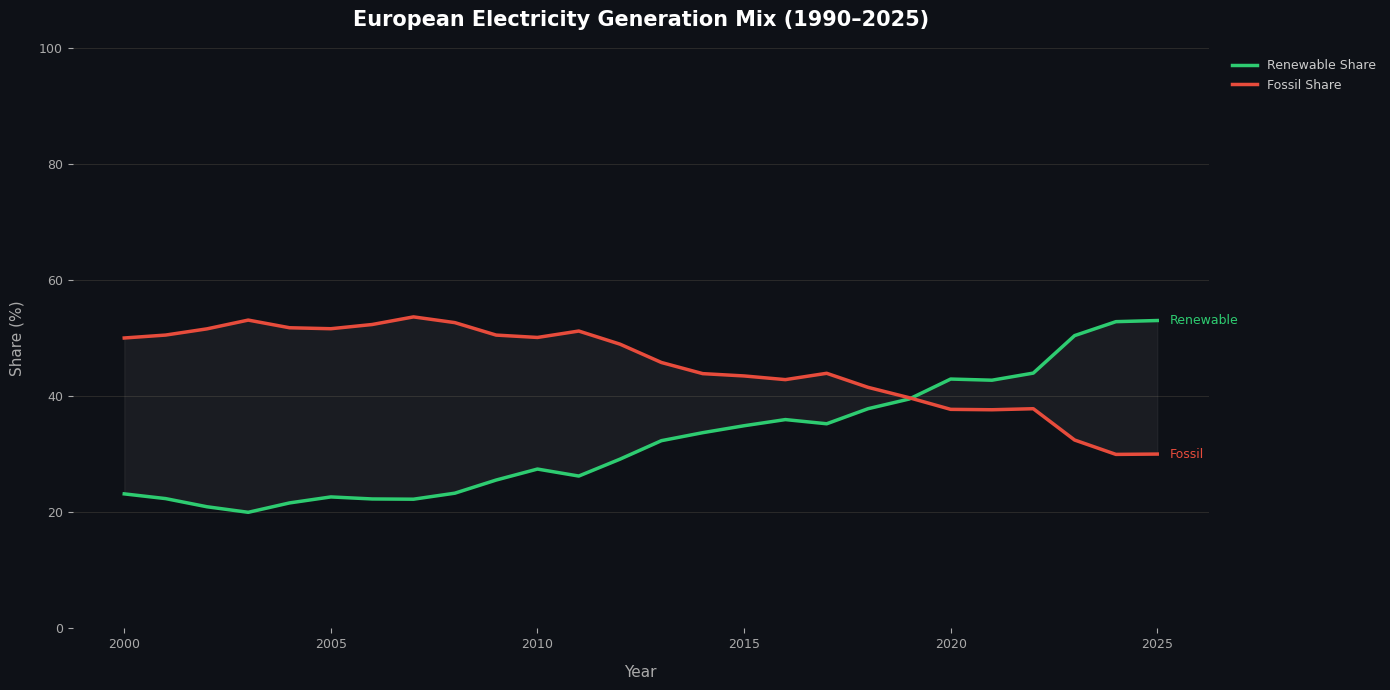

In [38]:
fig, ax = plt.subplots(figsize=(14, 7))

# Renewable share line — green
ax.plot(
    df_final["year"],
    df_final["renewable_share"] * 100,
    label="Renewable Share",
    color="#2ecc71",
    linewidth=2.5
)

# Fossil share line — red
ax.plot(
    df_final["year"],
    df_final["fossil_share"] * 100,
    label="Fossil Share",
    color="#e74c3c",
    linewidth=2.5
)

# Shade the area between both lines to visually highlight the gap
ax.fill_between(
    df_final["year"],
    df_final["renewable_share"] * 100,
    df_final["fossil_share"] * 100,
    alpha=0.08,
    color="#aaaaaa"
)

# Inline labels at the end of each line
for col, label, color in [
    ("renewable_share", "Renewable", "#2ecc71"),
    ("fossil_share", "Fossil", "#e74c3c")
]:
    last = df_final.iloc[-1]
    ax.text(
        last["year"] + 0.3,
        last[col] * 100,
        label,
        fontsize=9,
        color=color,
        va="center"
    )

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    "European Electricity Generation Mix (1990–2025)",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Year", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Share (%)", fontsize=11, color="#aaaaaa", labelpad=10)

# Lock Y axis to 0–100 since it's a percentage
ax.set_ylim(0, 100)

# Axis tick styling
ax.tick_params(axis="x", colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    labelcolor="#cccccc",
    fontsize=9
)

plt.tight_layout()
plt.show()

In [39]:
# Create country-level average generation ranking
country_generation_ranking = (
    df_country_final
    .groupby("area")["total_generation"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Renaming columns for clarity
country_generation_ranking.columns = ["Country", "Average Generation (TWh)"]

# Rounding values for better readability
country_generation_ranking["Average Generation (TWh)"] = \
    country_generation_ranking["Average Generation (TWh)"].round(2)

country_generation_ranking

,Country,Average Generation (TWh)
0,Germany,669.31
1,France,641.64
2,United Kingdom,439.60
3,Spain,350.51
4,Italy,339.25
5,Türkiye,330.98
6,Ukraine,271.83
7,Poland,253.14
8,Sweden,251.88
9,Norway,237.40


In [40]:
countries = [
    "Portugal",   
    "Spain",        
    "France",       
    "Germany",       
    "Denmark",   
    "Netherlands",
    "United Kingdom",
    "Italy",
    "Poland",
    "Belgium"
]

In [41]:
# Filtering dataset
df_selected = df_country_final[df_country_final["area"].isin(countries)]

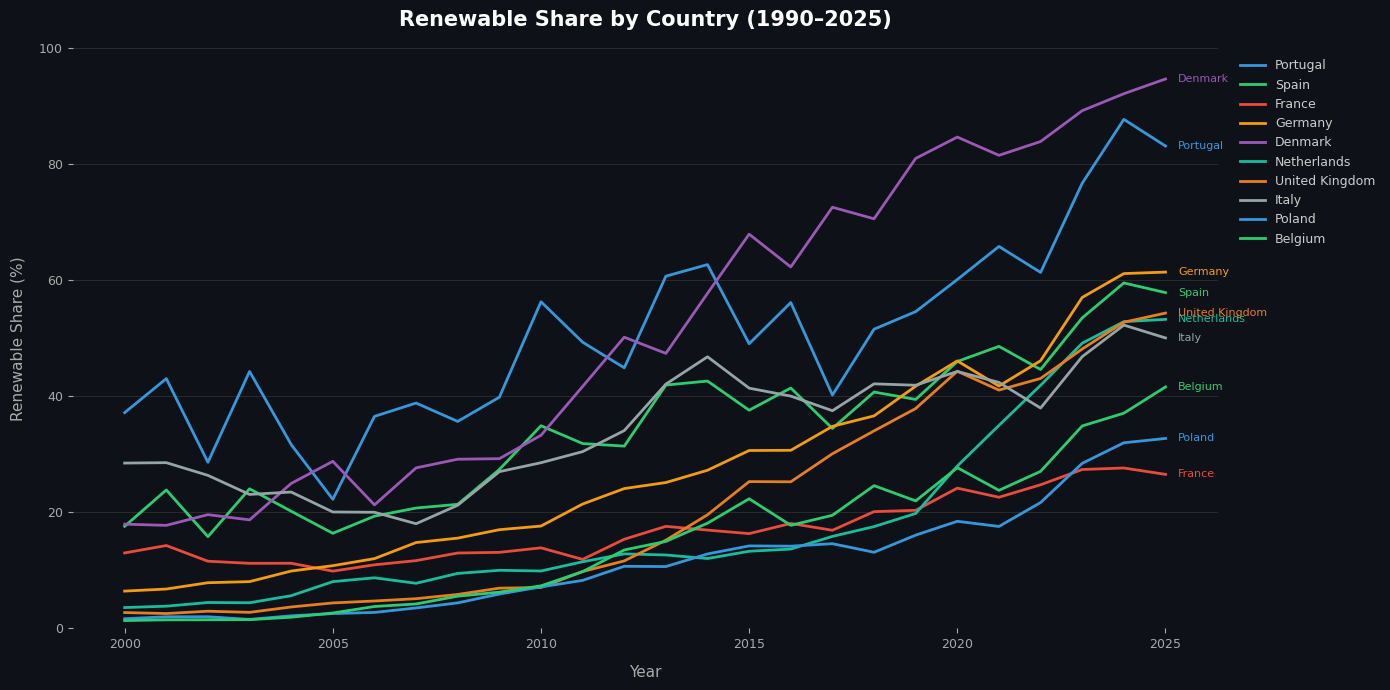

In [43]:
# Custom color palette — one distinct color per country
colors = [
    "#3498db", "#2ecc71", "#e74c3c", "#f39c12",
    "#9b59b6", "#1abc9c", "#e67e22", "#95a5a6"
]

fig, ax = plt.subplots(figsize=(14, 7))

# One line per country showing renewable share evolution over time
for i, country in enumerate(countries):
    data = df_selected[df_selected["area"] == country]
    ax.plot(
        data["year"],
        data["renewable_share"] * 100,
        label=country,
        linewidth=2,
        color=colors[i % len(colors)]
    )

    # Inline label at the end of each line — avoids looking back and forth to the legend
    last = data.iloc[-1]
    ax.text(
        last["year"] + 0.3,
        last["renewable_share"] * 100,
        country,
        fontsize=8,
        color=colors[i % len(colors)],
        va="center"
    )

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    "Renewable Share by Country (1990–2025)",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Year", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Renewable Share (%)", fontsize=11, color="#aaaaaa", labelpad=10)

# Lock Y axis to 0–100 since it's a percentage
ax.set_ylim(0, 100)

# Axis tick styling
ax.tick_params(axis="x", colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    labelcolor="#cccccc",
    fontsize=9
)

plt.tight_layout()
plt.show()

The selected countries reflect a **diverse set of energy systems** across Europe, ranging from renewable leaders to fossil-dependent economies. As shown in the chart, **Denmark leads in renewable energy share**, while Poland remains more reliant on fossil fuels. **Portugal performs strongly**, positioning itself above several large European economies.

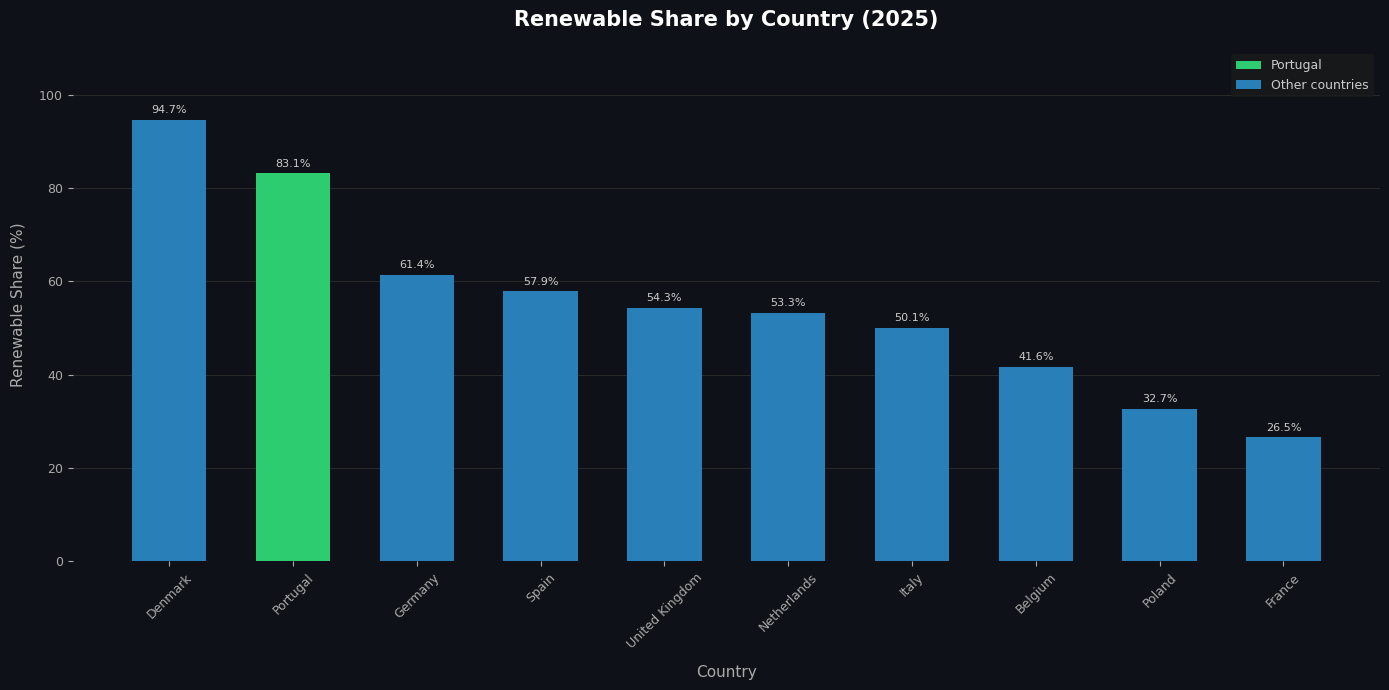

In [45]:
# Latest year available in the dataset
latest_year = df_selected["year"].max()

# Filter for latest year and sort by renewable share descending
df_latest = df_selected[df_selected["year"] == latest_year]
df_latest = df_latest.sort_values(by="renewable_share", ascending=False)

# Highlight Portugal in green, all other countries in muted blue
colors = ["#2ecc71" if c == "Portugal" else "#2980b9" for c in df_latest["area"]]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(
    df_latest["area"],
    df_latest["renewable_share"] * 100,
    color=colors,
    edgecolor="none",
    width=0.6
)

# Value label on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center", va="bottom",
        fontsize=8, color="#cccccc"
    )

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    f"Renewable Share by Country ({latest_year})",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Country", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Renewable Share (%)", fontsize=11, color="#aaaaaa", labelpad=10)

# Lock Y axis to 0–100 since it's a percentage
ax.set_ylim(0, 110)

# Axis tick styling
ax.tick_params(axis="x", rotation=45, colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Manual legend explaining the color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Portugal"),
    Patch(facecolor="#2980b9", label="Other countries"),
]
ax.legend(
    handles=legend_elements,
    facecolor="#1a1a1a",
    edgecolor="none",
    labelcolor="#cccccc",
    fontsize=9,
    loc="upper right"
)

plt.tight_layout()
plt.show()

The selected countries highlight **different pathways in reducing fossil fuel dependency**.

As shown in the chart, **France maintains a consistently low fossil fuel share**, largely due to its strong reliance on nuclear energy rather than renewable sources. In contrast, **Denmark demonstrates a significant decline in fossil dependency**, driven by rapid renewable energy adoption.

**Portugal shows a steady reduction in fossil fuel reliance**, indicating a balanced and consistent energy transition. Meanwhile, **Poland remains one of the most fossil-dependent systems**, with only gradual improvements over time.

Overall, the chart reveals that while fossil fuel dependency is declining across Europe, **the pace and drivers of this transition vary significantly by country**.

<Figure size 1200x600 with 0 Axes>

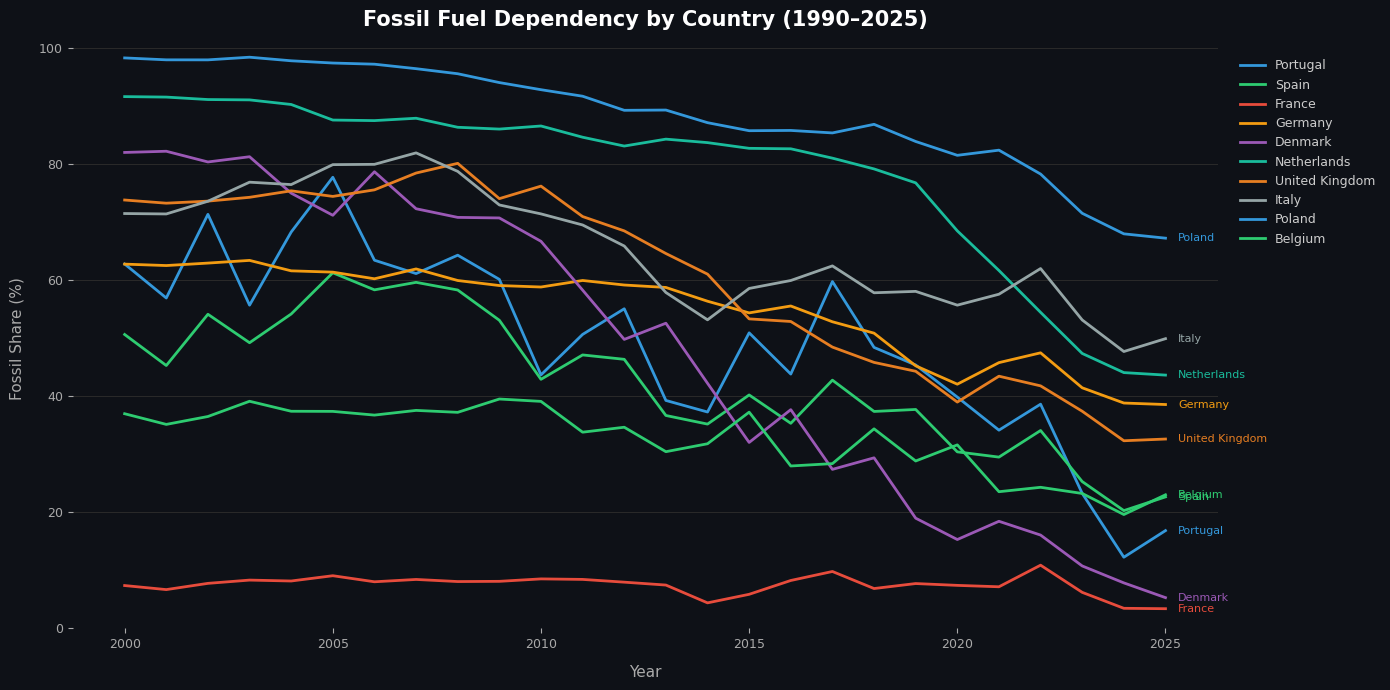

In [47]:
# Custom color palette — one distinct color per country

plt.figure(figsize=(12,6))

colors = [
    "#3498db", "#2ecc71", "#e74c3c", "#f39c12",
    "#9b59b6", "#1abc9c", "#e67e22", "#95a5a6"
]

fig, ax = plt.subplots(figsize=(14, 7))

# One line per country showing fossil share evolution over time
for i, country in enumerate(countries):
    data = df_selected[df_selected["area"] == country]
    ax.plot(
        data["year"],
        data["fossil_share"] * 100,
        label=country,
        linewidth=2,
        color=colors[i % len(colors)]
    )

    # Label at the end of each line — avoids crowded legend
    last = data.iloc[-1]
    ax.text(
        last["year"] + 0.3,
        last["fossil_share"] * 100,
        country,
        fontsize=8,
        color=colors[i % len(colors)],
        va="center"
    )

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    "Fossil Fuel Dependency by Country (1990–2025)",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Year", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Fossil Share (%)", fontsize=11, color="#aaaaaa", labelpad=10)

# Lock Y axis to 0–100 since it's a percentage
ax.set_ylim(0, 100)

# Axis tick styling
ax.tick_params(axis="x", colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    labelcolor="#cccccc",
    fontsize=9
)

plt.tight_layout()
plt.show()

**Electricity Generation Mix by Country**

This chart shows the composition of electricity generation across selected European countries.
It provides context for understanding differences in renewable adoption and fossil fuel dependency by revealing the underlying energy sources in each system.

<Figure size 1200x600 with 0 Axes>

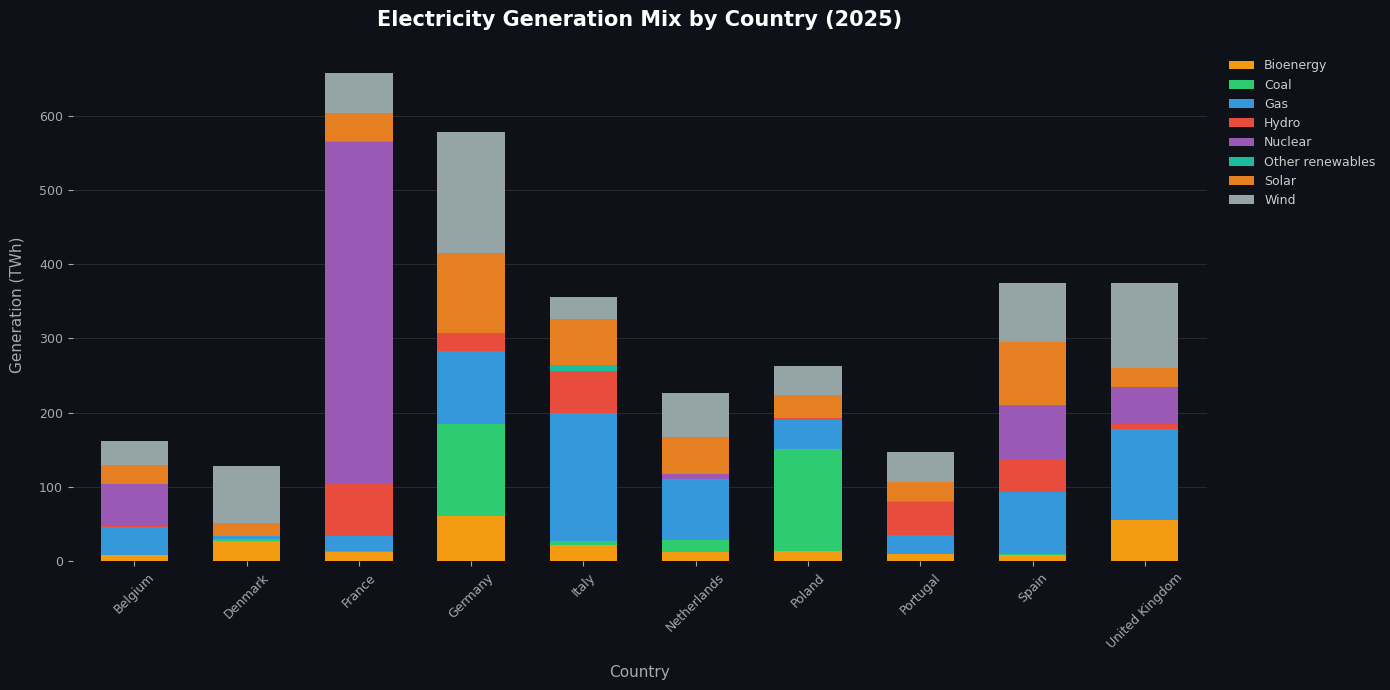

In [49]:
plt.figure(figsize=(12,6))

# Latest year available in the dataset
latest_year = df_country_total["year"].max()

# Filter for latest year and selected countries only
df_latest_mix = df_country_total[
    (df_country_total["year"] == latest_year) &
    (df_country_total["area"].isin(countries))
]

# Pivot so each energy source becomes its own column, countries as rows
df_pivot_mix = df_latest_mix.pivot(
    index="area",
    columns="variable",
    values="value"
)

# Custom color palette — one distinct color per energy source
colors = [
    "#f39c12", "#2ecc71", "#3498db", "#e74c3c",
    "#9b59b6", "#1abc9c", "#e67e22", "#95a5a6",
    "#2980b9", "#27ae60", "#c0392b", "#8e44ad"
]

fig, ax = plt.subplots(figsize=(14, 7))

# Stacked bar chart — compares energy mix across countries for the latest year
df_pivot_mix.plot(
    kind="bar",
    stacked=True,
    color=colors[:len(df_pivot_mix.columns)],
    edgecolor="none",
    width=0.6,
    ax=ax
)

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    f"Electricity Generation Mix by Country ({latest_year})",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Country", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Generation (TWh)", fontsize=11, color="#aaaaaa", labelpad=10)

# Axis tick styling — rotate country names for readability
ax.tick_params(axis="x", rotation=45, colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Legend outside the plot to avoid covering the bars
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
    labelcolor="#cccccc",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Case Study: France — A Low-Carbon System Without Heavy Renewable Reliance

<Figure size 1200x600 with 0 Axes>

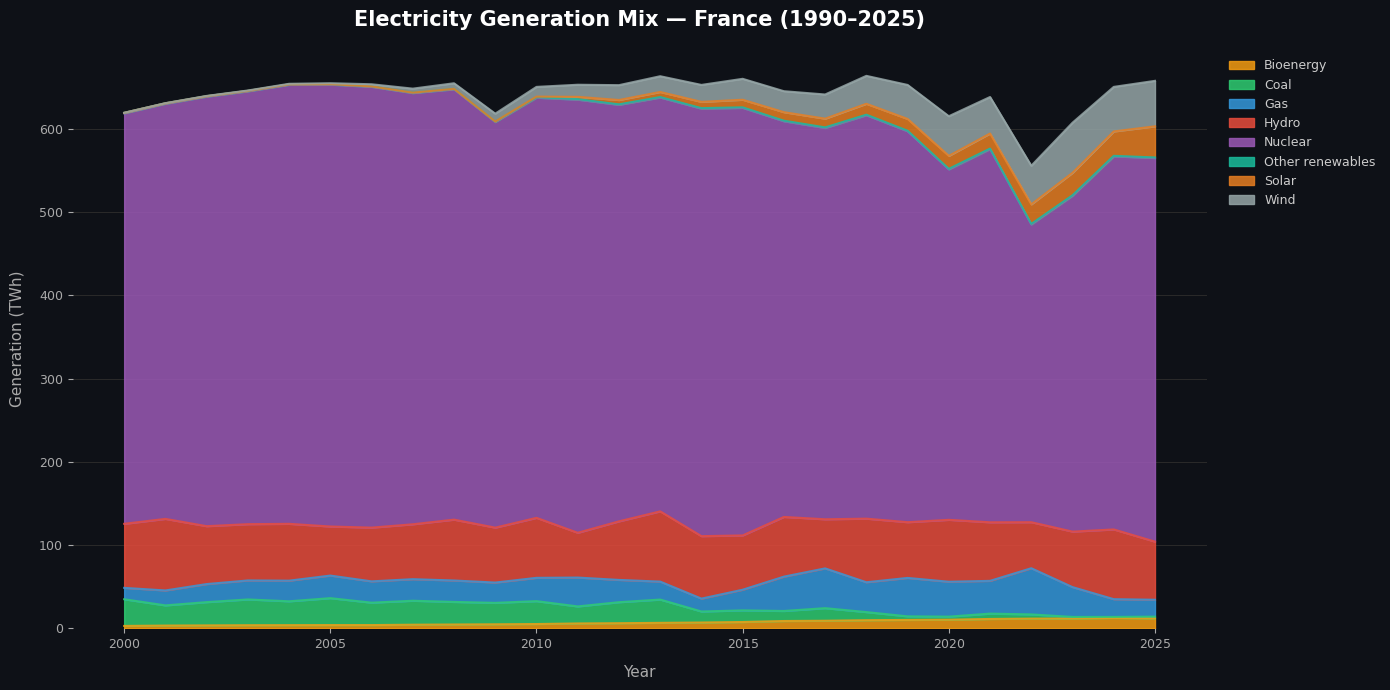

In [51]:
plt.figure(figsize=(12,6))

country = "France"

# Filter data for the selected country
df_country = df_country_total[df_country_total["area"] == country]

# Pivot so each energy source becomes its own column, years as rows
df_pivot = df_country.pivot(
    index="year",
    columns="variable",
    values="value"
)

# Custom color palette — one distinct color per energy source
colors = [
    "#f39c12", "#2ecc71", "#3498db", "#e74c3c",
    "#9b59b6", "#1abc9c", "#e67e22", "#95a5a6",
    "#2980b9", "#27ae60", "#c0392b", "#8e44ad"
]

fig, ax = plt.subplots(figsize=(14, 7))

# Stacked area chart — shows how the energy mix evolves over time
df_pivot.plot.area(
    stacked=True,
    alpha=0.85,
    color=colors[:len(df_pivot.columns)],
    ax=ax
)

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    f"Electricity Generation Mix — {country} (1990–2025)",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Year", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Generation (TWh)", fontsize=11, color="#aaaaaa", labelpad=10)

# Axis tick styling
ax.tick_params(axis="x", colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Legend outside the plot to avoid covering the chart
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    labelcolor="#cccccc",
    fontsize=9
)

plt.tight_layout()
plt.show()

France stands out among European countries for maintaining a **consistently low level of fossil fuel dependency** over time.

As shown in the energy mix, this is primarily driven by its **strong reliance on nuclear power**, which dominates electricity generation. Unlike countries such as Denmark or Portugal, France's transition has not been led by *rapid renewable expansion*, but rather by an already established **low-carbon foundation**.

This highlights an alternative pathway in the energy transition:  
while many countries reduce fossil dependency through renewables, France achieves similar outcomes through nuclear energy.

As a result, France presents a *unique case* where low emissions and low fossil dependency coexist without a high share of renewables. 

### Case Study: Portugal — A Diversified and Renewable-Driven Transition

<Figure size 1200x600 with 0 Axes>

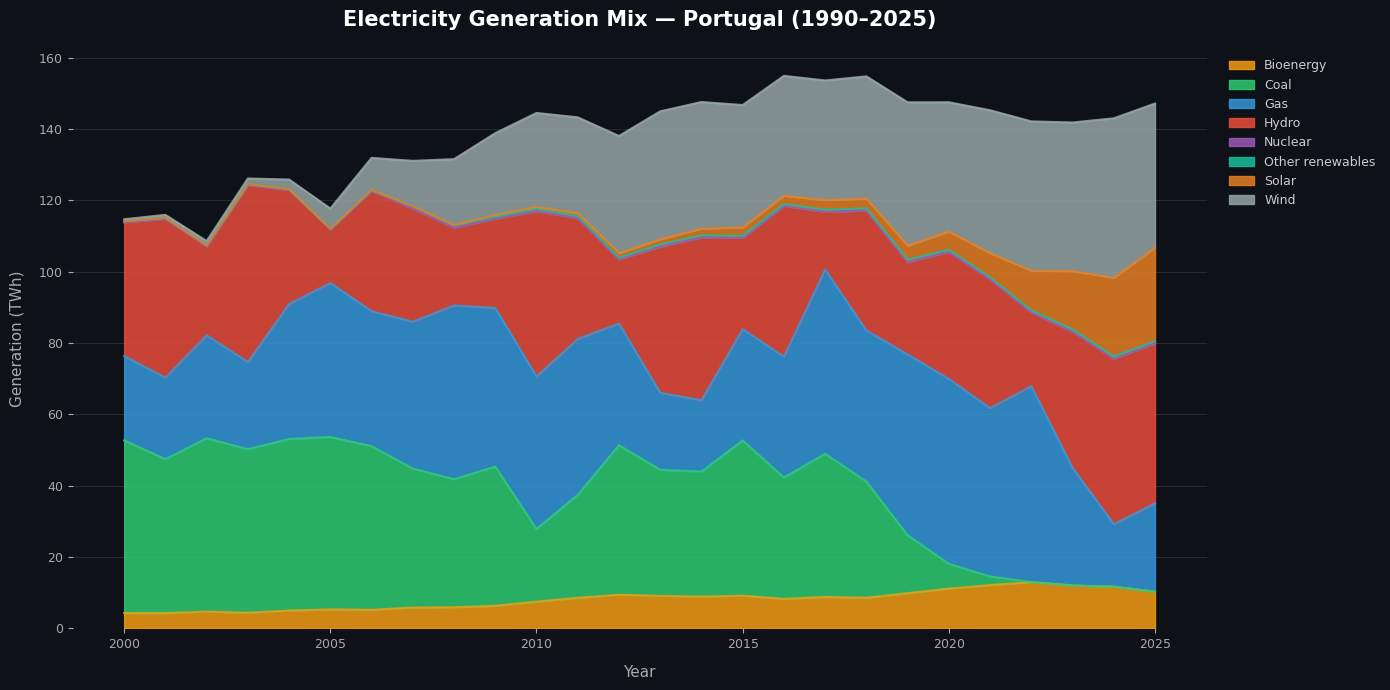

In [53]:
plt.figure(figsize=(12,6))

country_pt = "Portugal"

# Filter data for Portugal only
df_country_pt = df_country_total[df_country_total["area"] == country_pt]

# Pivot so each energy source becomes its own column, years as rows
df_pivot_pt = df_country_pt.pivot(
    index="year",
    columns="variable",
    values="value"
)

# Custom color palette — one distinct color per energy source
colors = [
    "#f39c12", "#2ecc71", "#3498db", "#e74c3c",
    "#9b59b6", "#1abc9c", "#e67e22", "#95a5a6",
    "#2980b9", "#27ae60", "#c0392b", "#8e44ad"
]

fig, ax = plt.subplots(figsize=(14, 7))

# Stacked area chart — shows how the energy mix evolves over time
df_pivot_pt.plot.area(
    stacked=True,
    alpha=0.85,
    color=colors[:len(df_pivot_pt.columns)],
    ax=ax
)

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    f"Electricity Generation Mix — {country_pt} (1990–2025)",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Year", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Generation (TWh)", fontsize=11, color="#aaaaaa", labelpad=10)

# Axis tick styling
ax.tick_params(axis="x", colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Legend outside the plot to avoid covering the chart
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    labelcolor="#cccccc",
    fontsize=9
)

plt.tight_layout()
plt.show()

Portugal presents a **well-balanced and progressively evolving** electricity system, driven primarily by **renewable energy expansion**.

The energy mix reveals a strong and sustained growth in **wind and hydro generation**, complemented by solar in more recent years. Unlike fossil-dependent systems, Portugal shows a clear reduction in fossil fuel contribution over time.

A key strength of Portugal’s transition is its **diversification across multiple renewable sources**, reducing reliance on any single technology and enhancing system resilience.

This results in a transition where **increasing renewable adoption** directly translates into **declining fossil dependency** — positioning Portugal as a strong example of a consistent and effective decarbonization pathway.

### Section 3 - Generation VS Demand

In [56]:
# Filter rows for electricity demand only
df_demand = df[
    (df["category"] == "Electricity demand") &
    (df["variable"] == "Demand")
]

# Filter rows for total electricity generation only
df_generation = df[
    (df["category"] == "Electricity generation") &
    (df["variable"] == "Total generation")
]

# Aggregate demand and generation by country and year
df_demand_grouped = df_demand.groupby(["area", "year"])["value"].sum().reset_index()
df_generation_grouped = df_generation.groupby(["area", "year"])["value"].sum().reset_index()

# Rename value column to be descriptive after the merge
df_demand_grouped.rename(columns={"value": "demand"}, inplace=True)
df_generation_grouped.rename(columns={"value": "generation"}, inplace=True)

# Merge both dataframes on country and year
df_balance = df_generation_grouped.merge(
    df_demand_grouped,
    on=["area", "year"]
)

# Calculate energy balance — positive means more generation than demand
df_balance["balance"] = df_balance["generation"] - df_balance["demand"]

# Keep only the latest year available
latest_year = df_balance["year"].max()
df_balance_latest = df_balance[df_balance["year"] == latest_year]

# Filter for selected countries only
df_balance_latest = df_balance_latest[df_balance_latest["area"].isin(countries)]

# Sort by balance descending — biggest surplus at the top
df_balance_latest = df_balance_latest.sort_values(by="balance", ascending=False)


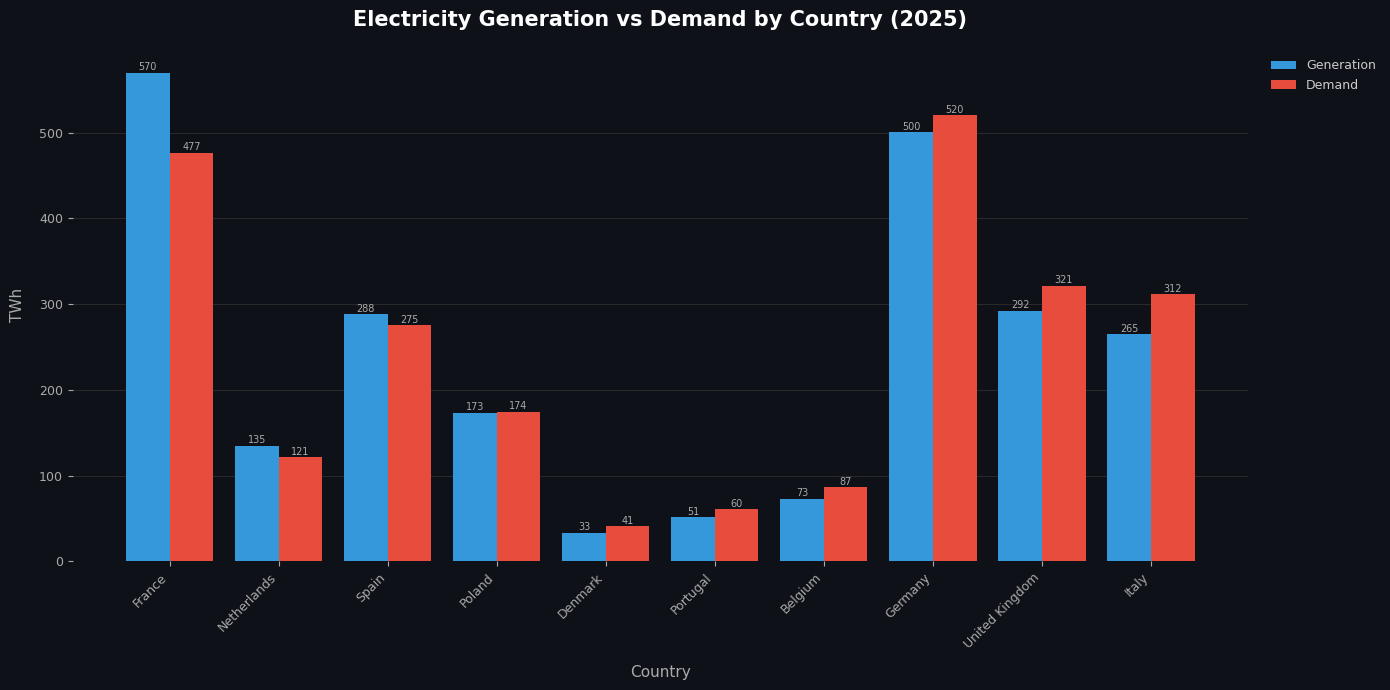

In [58]:
# X positions for grouped bars
x = range(len(df_balance_latest))

fig, ax = plt.subplots(figsize=(14, 7))

# Generation bars — blue
bars_gen = ax.bar(
    x,
    df_balance_latest["generation"],
    width=0.4,
    label="Generation",
    color="#3498db",
    edgecolor="none"
)

# Demand bars — offset to sit next to generation bars
bars_dem = ax.bar(
    [i + 0.4 for i in x],
    df_balance_latest["demand"],
    width=0.4,
    label="Demand",
    color="#e74c3c",
    edgecolor="none"
)

# Value labels on top of each bar
for bar in bars_gen:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.0f}",
        ha="center", va="bottom",
        fontsize=7, color="#aaaaaa"
    )

for bar in bars_dem:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.0f}",
        ha="center", va="bottom",
        fontsize=7, color="#aaaaaa"
    )

# Country labels centered between the two bars
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(df_balance_latest["area"], rotation=45, ha="right")

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    f"Electricity Generation vs Demand by Country ({latest_year})",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Country", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("TWh", fontsize=11, color="#aaaaaa", labelpad=10)

# Axis tick styling
ax.tick_params(axis="x", colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    labelcolor="#cccccc",
    fontsize=9
)

plt.tight_layout()
plt.show()

In [67]:
# Preparing data for Power BI charts

df_country_final = df_country_final.merge(
    df_balance[["area", "year", "generation", "demand"]],
    on=["area", "year"],
    how="left"
)

In [68]:

df_country_final["balance"] = df_country_final["generation"] - df_country_final["demand"]

In [69]:
df_country_final.to_csv("country_energy_transition_clean.csv", index=False)

### Electricity Import Dependency

Electricity imports provide a clearer view of energy independence across countries.

The chart shows that while some countries operate as *net exporters*, others **rely on external electricity supply** to meet domestic demand. For example, **France appears as a strong exporter** due to its high generation capacity, while countries such as **Italy and the United Kingdom show higher levels of import dependency**.

This highlights a key insight:
A higher **share of renewable energy does not necessarily translate into energy independence**. Structural factors such as total generation capacity, demand levels, and system design play a crucial role.

Overall, the European energy system reflects a **complex balance** between domestic production and cross-border electricity flows.

In [92]:
df_country_final_clean = df_country_final[
    [
        "area",
        "year",
        "total_generation",
        "renewable_generation",
        "fossil_generation",
        "renewable_share",
        "fossil_share",
        "renewable_yoy_growth",
        "generation",
        "demand",
        "balance",
        "imports"
    ]
].copy()

In [93]:
df_country_final_clean.head()
df_country_final_clean.columns

Index(['area', 'year', 'total_generation', 'renewable_generation',
       'fossil_generation', 'renewable_share', 'fossil_share',
       'renewable_yoy_growth', 'generation', 'demand', 'balance', 'imports'],
      dtype='object')

In [95]:
df_country_final_clean.to_csv("country_energy_transition_clean.csv", index=False)

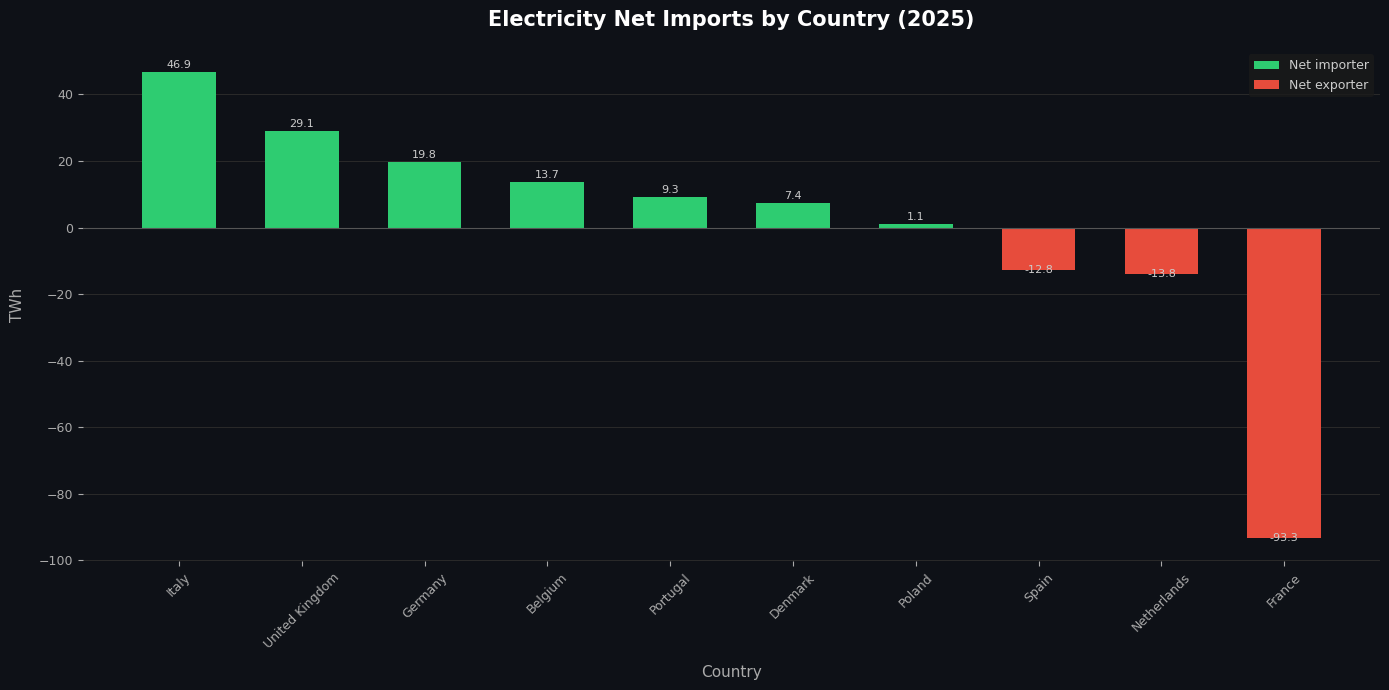

In [ ]:
latest_year = df_country_final_clean["year"].max()

df_imports_latest = df_country_final_clean[
    (df_country_final_clean["year"] == latest_year) &
    (df_country_final_clean["area"].isin(countries))
]

df_imports_latest = df_imports_latest.sort_values(by="imports", ascending=False)

# Color by value: green for net importers (positive), red for net exporters (negative)
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_imports_latest["imports"]]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(
    df_imports_latest["area"],
    df_imports_latest["imports"],
    color=colors,
    edgecolor="none",
    width=0.6
)

# Baseline at zero
ax.axhline(0, color="#555555", linewidth=0.8, linestyle="-")

# Value label above/below each bar
for bar, val in zip(bars, df_imports_latest["imports"]):
    offset = 0.5 if val >= 0 else -1.5
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f"{val:.1f}",
        ha="center", va="bottom",
        fontsize=8, color="#cccccc"
    )

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    f"Electricity Net Imports by Country ({latest_year})",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Country", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("TWh", fontsize=11, color="#aaaaaa", labelpad=10)

# Axis tick styling — removing spines for a cleaner look
ax.tick_params(axis="x", rotation=45, colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid lines only
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Manual legend explaining the color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Net importer"),
    Patch(facecolor="#e74c3c", label="Net exporter"),
]
ax.legend(handles=legend_elements, facecolor="#1a1a1a", edgecolor="none",
          labelcolor="#cccccc", fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

### Renewable Transition Speed

*Year-over-year growth* in renewable generation highlights **how quickly countries are advancing** their energy transition.

While some countries show **steady and consistent growth**, others experience **more volatile or slower progress**. This reveals that the transition is not only about reaching higher renewable shares, but also about the **pace at which change occurs**.

Understanding transition speed helps **identify leaders, late adopters**, and **systems** undergoing structural transformation.

In [59]:
df_growth_avg = (
    df_country_final
    .groupby("area")["renewable_yoy_growth"]
    .mean()
    .reset_index()
)

df_growth_avg = df_growth_avg[df_growth_avg["area"].isin(countries)]
df_growth_avg = df_growth_avg.sort_values(by="renewable_yoy_growth", ascending=False)

In [ ]:
# Calculating YoY growth for renewables at country level
# pct_change() compares each year's renewable generation to the previous year within the same country

df_country_final["renewable_yoy_growth"] = (
    df_country_final
    .sort_values(["area", "year"])
    .groupby("area")["renewable_generation"]
    .pct_change()
)

df_country_final.head(10)

,area,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share,renewable_yoy_growth
0,Austria,2000,152.60,116.28,36.32,0.761992,0.238008,NaN
1,Austria,2001,152.80,111.51,41.29,0.729777,0.270223,-0.041022
2,Austria,2002,153.19,111.01,42.18,0.724656,0.275344,-0.004484
3,Austria,2003,149.45,96.04,53.41,0.642623,0.357377,-0.134853
4,Austria,2004,153.02,103.67,49.35,0.677493,0.322507,0.079446
5,Austria,2005,155.98,104.40,51.58,0.669317,0.330683,0.007042
6,Austria,2006,153.05,106.01,47.04,0.692649,0.307351,0.015421
7,Austria,2007,154.64,111.88,42.76,0.723487,0.276513,0.055372
8,Austria,2008,156.37,113.70,42.67,0.727122,0.272878,0.016267
9,Austria,2009,158.86,118.44,40.42,0.745562,0.254438,0.041689


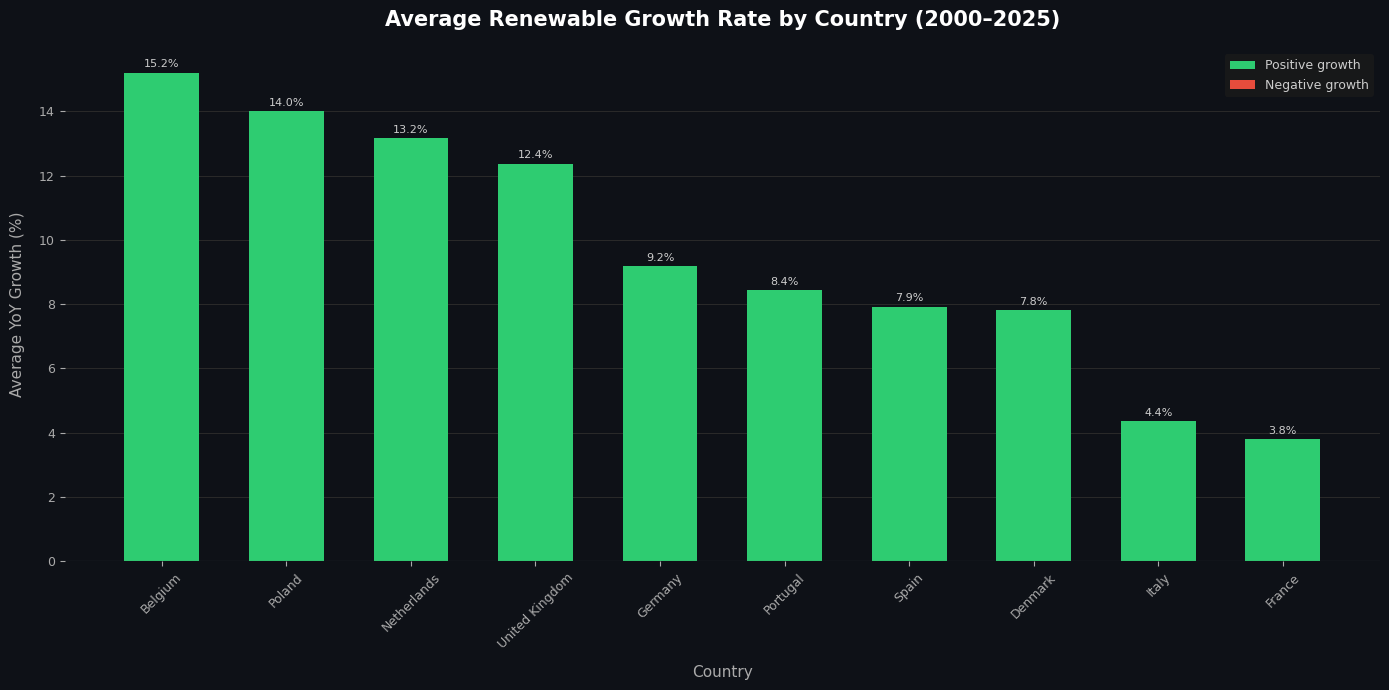

In [ ]:
# Color by value — green for positive growth, red for negative
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_growth_avg["renewable_yoy_growth"]]

fig, ax = plt.subplots(figsize=(14, 7))

# Bar chart — average year-over-year renewable growth per country
bars = ax.bar(
    df_growth_avg["area"],
    df_growth_avg["renewable_yoy_growth"] * 100,
    color=colors,
    edgecolor="none",
    width=0.6
)

# Value label on top/bottom of each bar
for bar, val in zip(bars, df_growth_avg["renewable_yoy_growth"] * 100):
    offset = 0.1 if val >= 0 else -0.3
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f"{val:.1f}%",
        ha="center", va="bottom",
        fontsize=8, color="#cccccc"
    )

# Baseline at zero
ax.axhline(0, color="#555555", linewidth=0.8)

# Dark background
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Title and axis labels
ax.set_title(
    "Average Renewable Growth Rate by Country (2000–2025)",
    fontsize=15, fontweight="bold", color="#ffffff", pad=16
)
ax.set_xlabel("Country", fontsize=11, color="#aaaaaa", labelpad=10)
ax.set_ylabel("Average YoY Growth (%)", fontsize=11, color="#aaaaaa", labelpad=10)

# Axis tick styling
ax.tick_params(axis="x", rotation=45, colors="#aaaaaa", labelsize=9)
ax.tick_params(axis="y", colors="#aaaaaa", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle horizontal grid
ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.7)
ax.set_axisbelow(True)

# Manual legend explaining color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Positive growth"),
    Patch(facecolor="#e74c3c", label="Negative growth"),
]
ax.legend(
    handles=legend_elements,
    facecolor="#1a1a1a",
    edgecolor="none",
    labelcolor="#cccccc",
    fontsize=9,
    loc="upper right"
)

plt.tight_layout()
plt.show()

### Average Renewable Growth Rate by Country (2000–2025)

This chart shows the **average year-over-year (YoY) growth rate** of renewable electricity generation per country.

For each country, `renewable_yoy_growth` is calculated by comparing renewable generation in a given year to the previous year (`pct_change()`). The chart then shows the **mean of all those annual percentages** between 2000 and 2025.

**How to read it:**
- A country at **5%** grew its renewable generation by 5% on average each year
- A country in **negative** values saw its renewable generation decline on average
- This metric reflects **growth speed**, not absolute level — a country can have high renewable share but low growth if it already reached its ceiling

> This chart does not show how much renewable energy a country produces — it shows how fast they have been scaling it up.

## Final Conclusion

The European energy transition is clearly underway, with all analyzed countries increasing their share of renewable energy over time. However, the results show that progress is neither uniform nor linear.

Countries such as **Denmark and Portugal** demonstrate strong renewable adoption, positioning themselves as leaders in the transition. In contrast, others maintain higher levels of fossil dependency or show slower rates of change, reflecting structural and policy differences across energy systems.

Importantly, the analysis reveals that renewable adoption alone does not fully define system performance. Factors such as **total generation capacity, demand levels**, and **reliance on electricity imports** play a critical role in shaping energy independence and system resilience.

This highlights a key insight:  
The energy transition is not a single pathway, but a set of distinct national strategies influenced by geography, infrastructure, and policy choices.

Overall, while Europe is moving toward a lower-carbon future, the transition remains complex and uneven, requiring a multidimensional approach to fully understand its progress and implications.

### Data Sources:
[Ember Energy](https://ember-energy.org/data/yearly-electricity-data/)

"Summary: This dataset contains yearly electricity generation, capacity, emissions, import and demand data for over 200 geographies. Data is collected from **multi-country datasets** *(EIA, Eurostat, BP, UN)* as well as national sources *(e.g China data from the National Bureau of Statistics)*.

Our yearly electricity data is kept up to date throughout the year and is regularly amended with the latest available data. The data is updated twice a month with an update in the first week of the month followed by a second update in the third week of the month."